In [99]:
# to handle the data
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

import numpy as np

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV

# pipeline
from sklearn.pipeline import Pipeline

# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

#warnings
import warnings
warnings.filterwarnings('ignore')


In [78]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [79]:
df.shape

(1338, 7)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


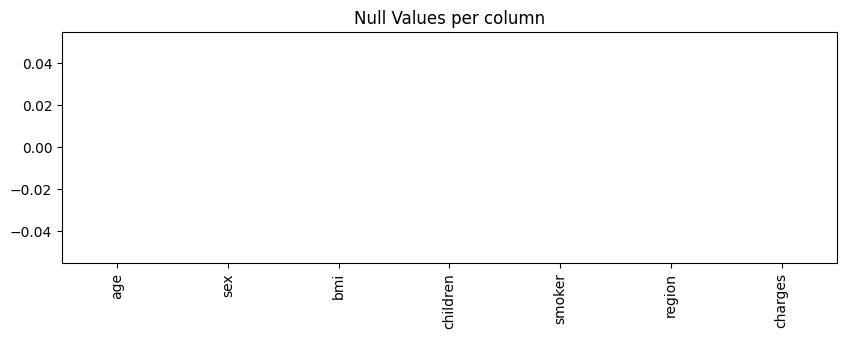

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [81]:
df.isnull().sum().plot(kind="bar", figsize=(10,3))
plt.title("Null Values per column")
plt.show()

df.isnull().sum()

In [82]:
df.duplicated().sum()

np.int64(1)

In [83]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_col)

['age', 'bmi', 'children', 'charges']


In [84]:
cat_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_col)

['sex', 'smoker', 'region']


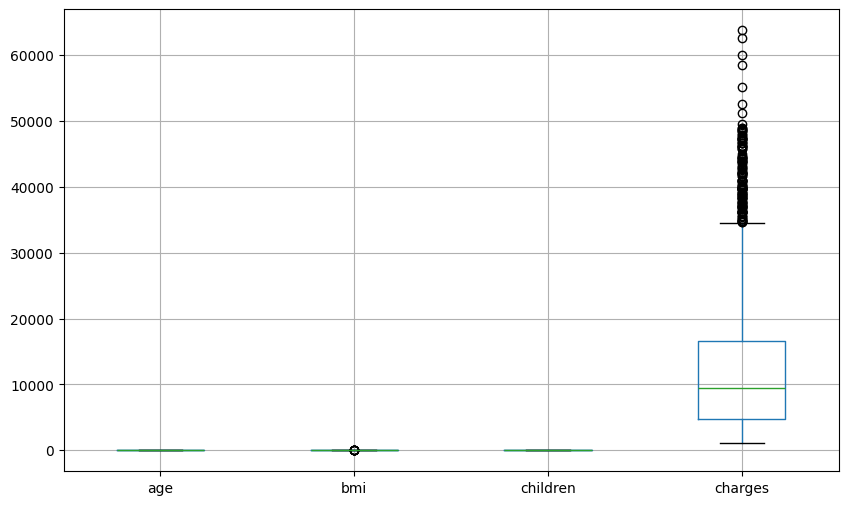

In [85]:
df.boxplot(figsize=(10,6))
plt.show()

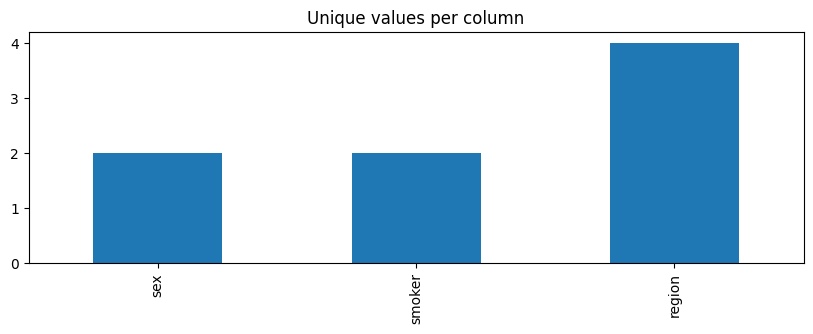

sex : ['female' 'male']
smoker : ['yes' 'no']
region : ['southwest' 'southeast' 'northwest' 'northeast']


In [86]:
df[cat_col].nunique().plot(kind="bar", figsize=(10,3))
plt.title("Unique values per column")
plt.show()
for col in cat_col:
    print(f'{col} : {df[col].unique()}')

In [87]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])


In [88]:
df = pd.get_dummies(df, columns=['region'])

In [89]:
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,False,True,False,False
1334,18,0,31.920,0,0,2205.98080,True,False,False,False
1335,18,0,36.850,0,0,1629.83350,False,False,True,False
1336,21,0,25.800,0,0,2007.94500,False,False,False,True


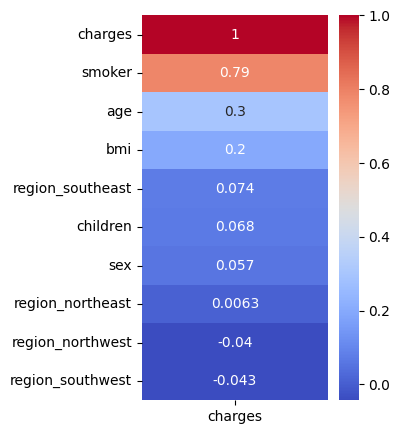

In [90]:
corr = df.corr()

plt.figure(figsize=(3,5))
sns.heatmap(corr[['charges']].sort_values(by='charges', ascending=False), 
            annot=True, cmap="coolwarm")
plt.show()

In [91]:
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
from sklearn.ensemble import GradientBoostingRegressor


gbr = GradientBoostingRegressor()

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)



In [93]:
print("MEAN ABSOLUTE ERROR:", mean_absolute_error(y_test, y_pred))
print("MEAN SQUARED ERROR:", mean_squared_error(y_test, y_pred))
print("R2 SCORE:", r2_score(y_test, y_pred))

cv_scores_reg = cross_val_score(gbr, X, y, cv=5)
print("CROSS-VAL SCORES:", cv_scores_reg)
print("CV MEAN:", np.mean(cv_scores_reg))


MEAN ABSOLUTE ERROR: 2409.491678096033
MEAN SQUARED ERROR: 18777857.135527387
R2 SCORE: 0.8790466308156443
CROSS-VAL SCORES: [0.87275319 0.79977201 0.89263595 0.84890036 0.86040822]
CV MEAN: 0.8548939484969342


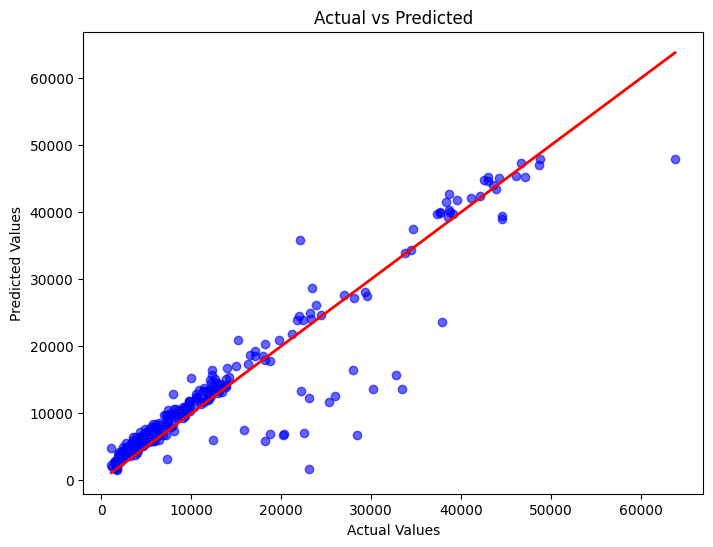

In [94]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.05, 0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5, 7, 10]
}

gbr = GradientBoostingRegressor()
grid_search = GridSearchCV(gbr, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

In [103]:
random_search = RandomizedSearchCV(gbr, param_distributions=param_grid, n_iter=5, cv=5, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)
print(random_search.best_params_)


{'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.01}


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

print("MEAN ABSOLUTE ERROR:", mean_absolute_error(y_test, y_pred))
print("MEAN SQUARED ERROR:", mean_squared_error(y_test, y_pred))
print("R2 SCORE:", r2_score(y_test, y_pred))

cv_scores_reg = cross_val_score(gbr, X, y, cv=5)
print("CROSS-VAL SCORES:", cv_scores_reg)
print("CV MEAN:", np.mean(cv_scores_reg))



In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()